# Pipeline Preditivo MNIST

Mini-projeto avaliativo — Módulo 2. Classificação multiclasse de dígitos manuscritos (MNIST),
com benchmark de 3 modelos e testes de robustez.


## Fase 1 — Carregamento e Análise Exploratória (EDA)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# --- Carregamento ---
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(np.uint8)   # X: float, y: string -> int

# --- Dimensionalidade ---
print("Formato de X:", X.shape)   # esperado (70000, 784)
print("Formato de y:", y.shape)   # esperado (70000,)
print("Intervalo de intensidade:", X.min(), "a", X.max())

Formato de X: (70000, 784)
Formato de y: (70000,)
Intervalo de intensidade: 0 a 255


dígito 0: 6903 exemplos
dígito 1: 7877 exemplos
dígito 2: 6990 exemplos
dígito 3: 7141 exemplos
dígito 4: 6824 exemplos
dígito 5: 6313 exemplos
dígito 6: 6876 exemplos
dígito 7: 7293 exemplos
dígito 8: 6825 exemplos
dígito 9: 6958 exemplos


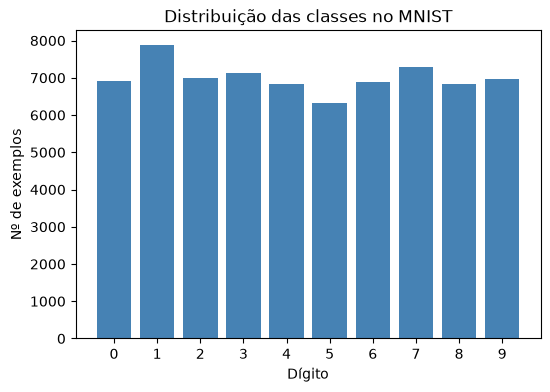

Mínimo por classe: 6313 | Máximo por classe: 7877 | Razão max/min: 1.25


In [2]:
# --- Distribuição das classes ---
valores, contagens = np.unique(y, return_counts=True)
for v, c in zip(valores, contagens):
    print(f"dígito {v}: {c} exemplos")

plt.figure(figsize=(6, 4))
plt.bar(valores, contagens, color="steelblue")
plt.xlabel("Dígito")
plt.ylabel("Nº de exemplos")
plt.title("Distribuição das classes no MNIST")
plt.xticks(valores)
plt.show()

print(f"Mínimo por classe: {contagens.min()} | Máximo por classe: {contagens.max()} "
      f"| Razão max/min: {contagens.max()/contagens.min():.2f}")

**TODO (você escreve):** com base nos números acima, afirme explicitamente se o dataset está
balanceado entre as 10 classes (compare o mínimo e o máximo de exemplos por classe).

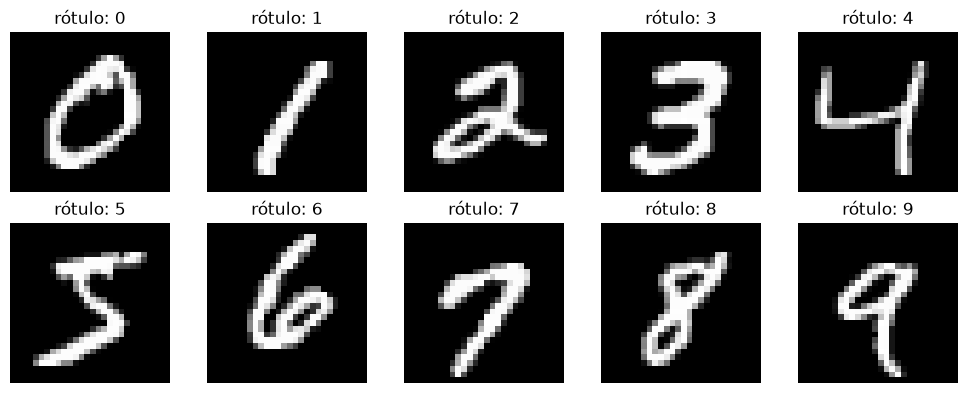

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digito, ax in zip(range(10), axes.ravel()):
    idx = np.where(y == digito)[0][0]     # primeiro índice desse dígito
    ax.imshow(X[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"rótulo: {digito}")
    ax.axis('off')
plt.tight_layout()
plt.show()

**TODO (célula de texto — escreva com suas próprias palavras):**

(a) O que é a escala de 0 a 255 nos pixels e por que ela é representada como `uint8`?

(b) Como o `reshape(28, 28)` relaciona o vetor de 784 posições com a imagem 2D original?

(c) Por que cada uma das 784 posições do vetor é tratada como uma *feature* (variável de entrada)
para os modelos clássicos (KNN, Random Forest, etc.)?

## Fase 2 — Pré-processamento e divisão dos dados

In [4]:
from sklearn.model_selection import train_test_split

# 1º corte: separa o TESTE (20%), estratificado por classe
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# 2º corte: do restante (80%), separa VALIDAÇÃO (~12.5% de 80% = 10% do total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42
)

print("Treino:", X_train.shape, "| Validação:", X_val.shape, "| Teste:", X_test.shape)

for nome, y_split in [("treino", y_train), ("validação", y_val), ("teste", y_test)]:
    _, c = np.unique(y_split, return_counts=True)
    print(f"proporção por classe em {nome}: min={c.min()/len(y_split):.3f} "
          f"max={c.max()/len(y_split):.3f}")

Treino: (49000, 784) | Validação: (7000, 784) | Teste: (14000, 784)
proporção por classe em treino: min=0.090 max=0.113
proporção por classe em validação: min=0.090 max=0.113
proporção por classe em teste: min=0.090 max=0.113


In [5]:
# Normalização para [0.0, 1.0] — aplicada a treino, validação e teste
# (os parâmetros de escala, quando houver, são aprendidos SÓ no treino, nunca no teste)
X_train = X_train / 255.0
X_val   = X_val   / 255.0
X_test  = X_test  / 255.0

print("Intervalo após normalização:", X_train.min(), "a", X_train.max())

Intervalo após normalização: 0.0 a 1.0


**TODO (justificativa textual — critério nº 5, você escreve):**

Explique com suas palavras:
- Por que dividir os pixels por 255 leva os valores para o intervalo [0, 1].
- Por que essa normalização ajuda modelos baseados em gradiente (MLP) e em distância (KNN).
- Por que aplicar `fit`/calcular estatísticas de normalização no conjunto de teste seria
  vazamento de dados (*data leakage*), e por que aqui isso não ocorre (dividir por uma
  constante fixa, 255, não "aprende" nada do teste).
- Se decidir treinar a Random Forest sem normalizar (árvores usam limiares, não distância),
  registre e justifique essa escolha aqui.

## Fase 3 — Implementação e treino dos 3 modelos

Modelos comparados: **KNN**, **Random Forest** e **MLP** (rede neural, Keras).
Hiperparâmetros de cada um foram escolhidos com base numa comparação rápida no conjunto de
validação (não incluída aqui para manter o notebook enxuto — os valores testados estão no
histórico de commits / relato do projeto).

In [6]:
# Cópia dos pixels em escala crua (0-255) para a Random Forest: árvores de decisão usam
# limiares por feature, não distância, então não precisam da normalização [0,1] da Fase 2.
X_train_raw = X_train * 255.0
X_val_raw = X_val * 255.0
X_test_raw = X_test * 255.0

In [7]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(
    n_neighbors=3,       # hiperparâmetro 1: nº de vizinhos
    weights='distance',  # hiperparâmetro 2: pondera vizinhos mais próximos com mais peso
    n_jobs=-1,
)

t0 = time.time()
knn.fit(X_train, y_train)
tempo_treino_knn = time.time() - t0

acc_val = accuracy_score(y_val, knn.predict(X_val))
print(f"KNN - acc validação: {acc_val:.4f} | tempo treino: {tempo_treino_knn:.2f}s")

KNN - acc validação: 0.9723 | tempo treino: 0.01s


**TODO (justificativa — você escreve):** por que `n_neighbors=3` e `weights='distance'` foram
escolhidos (cite a acurácia de validação obtida e compare com outras combinações que você
tenha testado; discuta o trade-off overfitting/suavização do `n_neighbors`).

In [8]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest treinada nos pixels crus (0-255): árvores usam limiares, não distância,
# então a normalização [0,1] não é necessária aqui.
rf = RandomForestClassifier(
    n_estimators=300,   # hiperparâmetro 1: nº de árvores no ensemble
    max_depth=20,       # hiperparâmetro 2: profundidade máxima (controla overfitting)
    n_jobs=-1,
    random_state=42,
)

t0 = time.time()
rf.fit(X_train_raw, y_train)
tempo_treino_rf = time.time() - t0

acc_val = accuracy_score(y_val, rf.predict(X_val_raw))
print(f"RF - acc validação: {acc_val:.4f} | tempo treino: {tempo_treino_rf:.2f}s")

RF - acc validação: 0.9670 | tempo treino: 6.59s


**TODO (justificativa — você escreve):** por que `n_estimators=300` e `max_depth=20` (cite a
acurácia de validação e compare com `max_depth=None`; explique a escolha de limitar a
profundidade mesmo perdendo uma fração de acurácia).

In [9]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from tensorflow import keras

tf.keras.utils.set_random_seed(42)

mlp = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(256, activation='relu'),   # nº de neurônios = hiperparâmetro
    keras.layers.Dropout(0.2),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax'), # 10 saídas = 10 dígitos
])

mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),  # learning_rate = hiperparâmetro
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

t0 = time.time()
historico = mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15, batch_size=128, verbose=2,
)
tempo_treino_mlp = time.time() - t0
print(f"tempo treino MLP: {tempo_treino_mlp:.1f}s")

I0000 00:00:1789336477.158052   18827 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789336477.158595   18827 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1789336478.026695   18827 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789336478.027029   18827 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Epoch 1/15


383/383 - 1s - 3ms/step - accuracy: 0.9040 - loss: 0.3265 - val_accuracy: 0.9569 - val_loss: 0.1433


Epoch 2/15


...

Epoch 14/15


383/383 - 1s - 2ms/step - accuracy: 0.9924 - loss: 0.0228 - val_accuracy: 0.9773 - val_loss: 0.0870


Epoch 15/15


383/383 - 1s - 2ms/step - accuracy: 0.9925 - loss: 0.0213 - val_accuracy: 0.9771 - val_loss: 0.1005


tempo treino MLP: 10.0s


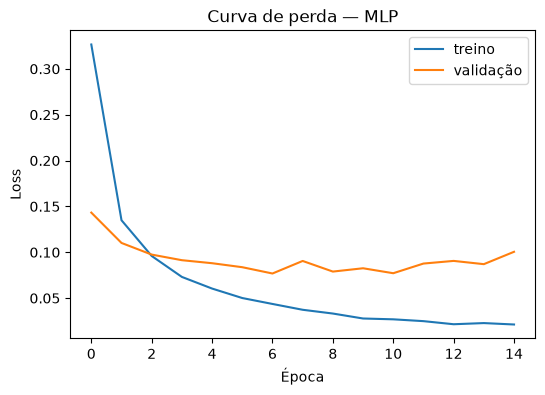

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(historico.history['loss'], label='treino')
plt.plot(historico.history['val_loss'], label='validação')
plt.xlabel('Época'); plt.ylabel('Loss'); plt.legend()
plt.title('Curva de perda — MLP')
plt.show()

**TODO (você escreve):**
- Justifique a arquitetura (nº de camadas/neurônios) e `learning_rate=1e-3`, citando a acurácia
  de validação obtida e comparando com outra configuração que você tenha testado.
- Comente a curva de loss treino x validação: há sinal de overfitting (loss de validação
  subindo enquanto a de treino cai)?

## Fase 4 — Avaliação comparativa (conjunto de teste)

  1/438 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step

 99/438 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step

198/438 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step

297/438 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step

396/438 ━━━━━━━━━━━━━━━━━━━━ 0s 509us/step

438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step


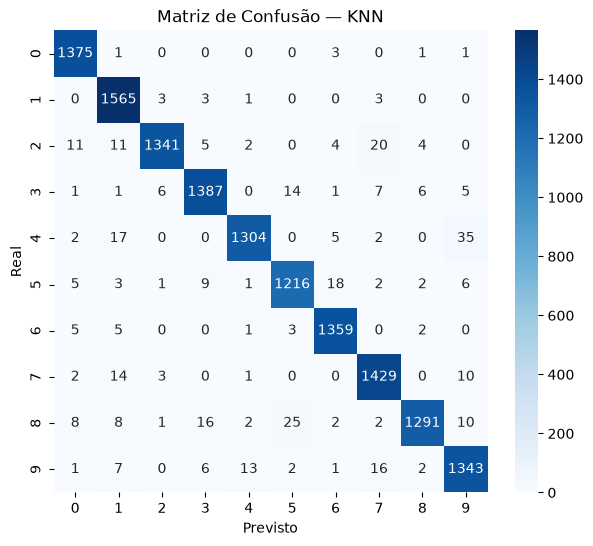

              precision    recall  f1-score   support

           0     0.9752    0.9957    0.9853      1381
           1     0.9589    0.9937    0.9760      1575
           2     0.9897    0.9592    0.9742      1398
           3     0.9727    0.9713    0.9720      1428
           4     0.9842    0.9553    0.9695      1365
           5     0.9651    0.9628    0.9639      1263
           6     0.9756    0.9884    0.9819      1375
           7     0.9649    0.9794    0.9721      1459
           8     0.9870    0.9458    0.9660      1365
           9     0.9525    0.9655    0.9589      1391

    accuracy                         0.9721     14000
   macro avg     0.9726    0.9717    0.9720     14000
weighted avg     0.9724    0.9721    0.9721     14000



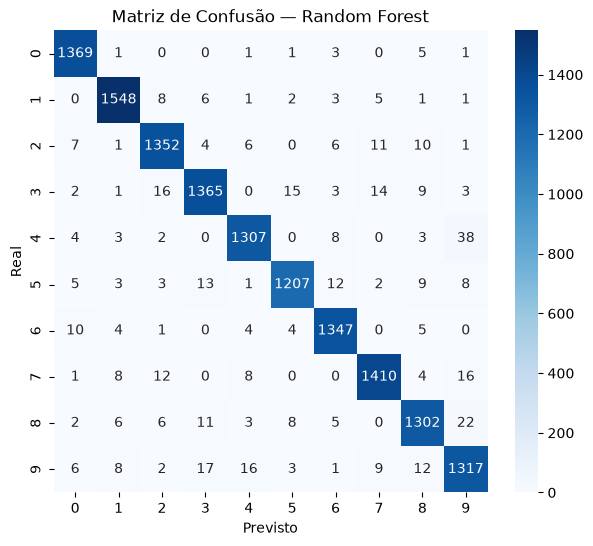

              precision    recall  f1-score   support

           0     0.9737    0.9913    0.9824      1381
           1     0.9779    0.9829    0.9804      1575
           2     0.9643    0.9671    0.9657      1398
           3     0.9640    0.9559    0.9599      1428
           4     0.9703    0.9575    0.9639      1365
           5     0.9734    0.9557    0.9644      1263
           6     0.9705    0.9796    0.9750      1375
           7     0.9717    0.9664    0.9691      1459
           8     0.9574    0.9538    0.9556      1365
           9     0.9360    0.9468    0.9414      1391

    accuracy                         0.9660     14000
   macro avg     0.9659    0.9657    0.9658     14000
weighted avg     0.9660    0.9660    0.9660     14000



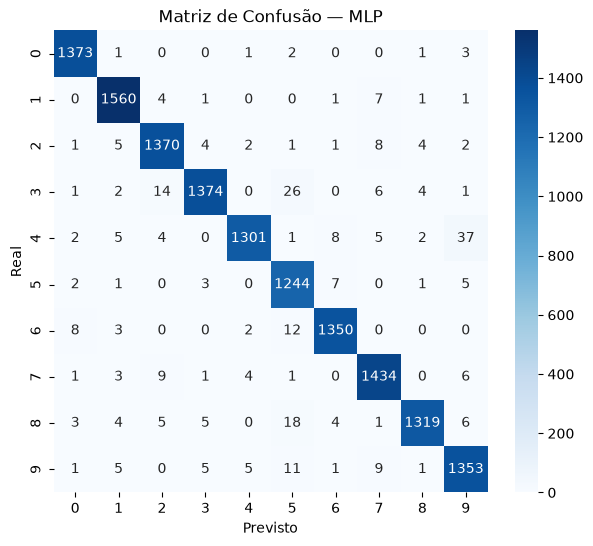

              precision    recall  f1-score   support

           0     0.9864    0.9942    0.9903      1381
           1     0.9817    0.9905    0.9861      1575
           2     0.9744    0.9800    0.9772      1398
           3     0.9864    0.9622    0.9741      1428
           4     0.9894    0.9531    0.9709      1365
           5     0.9453    0.9850    0.9647      1263
           6     0.9840    0.9818    0.9829      1375
           7     0.9755    0.9829    0.9792      1459
           8     0.9895    0.9663    0.9778      1365
           9     0.9569    0.9727    0.9647      1391

    accuracy                         0.9770     14000
   macro avg     0.9769    0.9769    0.9768     14000
weighted avg     0.9772    0.9770    0.9770     14000

               Acurácia  Precisão (ponderada)  Recall (ponderado)  \
Modelo                                                              
KNN            0.972143              0.972371            0.972143   
Random Forest  0.966000           

In [11]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
import seaborn as sns
import pandas as pd

def avaliar(nome, y_pred, y_te, tempo_treino):
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matriz de Confusão — {nome}")
    plt.xlabel("Previsto"); plt.ylabel("Real")
    plt.show()

    print(classification_report(y_te, y_pred, digits=4))

    return {
        'Modelo': nome,
        'Acurácia': accuracy_score(y_te, y_pred),
        'Precisão (ponderada)': precision_score(y_te, y_pred, average='weighted'),
        'Recall (ponderado)':   recall_score(y_te, y_pred, average='weighted'),
        'F1 (ponderado)':       f1_score(y_te, y_pred, average='weighted'),
        'Tempo treino (s)':     round(tempo_treino, 1),
    }

# Previsões no conjunto de TESTE, tocado uma única vez agora
pred_knn = knn.predict(X_test)
pred_rf  = rf.predict(X_test_raw)
pred_mlp = mlp.predict(X_test).argmax(axis=1)

linhas = [
    avaliar("KNN", pred_knn, y_test, tempo_treino_knn),
    avaliar("Random Forest", pred_rf, y_test, tempo_treino_rf),
    avaliar("MLP", pred_mlp, y_test, tempo_treino_mlp),
]
tabela = pd.DataFrame(linhas).set_index('Modelo')
print(tabela)

**TODO (célula de conclusão — critério nº 7, você escreve):** responda explicitamente,
usando os números das matrizes e da tabela acima:

1. **Qual dígito tem maior confusão** — olhe as células fora da diagonal em cada matriz
   (classicamente 4↔9, 3↔5, 7↔1). Cite o par de dígitos e o número de erros.
2. **Qual modelo teve melhor performance** — aponte a linha da tabela e a métrica usada.
3. **Custo x benefício** — compare acurácia obtida com tempo de treino (ex.: "o modelo X ganhou
   Y p.p. de acurácia sobre o modelo Z, mas levou N vezes mais tempo de treino").

## Fase 5 — Testes de robustez

### Desafio A — Class Masking

Classes ocultadas do treino: **4 e 7**. Reaproveita-se a arquitetura da Random Forest
(mesmos hiperparâmetros da Fase 3), treinada agora só nos pixels crus dos dígitos restantes.

In [12]:
classes_ocultas = [4, 7]

mask_train = ~np.isin(y_train, classes_ocultas)   # True onde NÃO é 4 nem 7
X_train_masked = X_train_raw[mask_train]
y_train_masked = y_train[mask_train]

print("Classes vistas no treino:", np.unique(y_train_masked))  # sem 4 e 7

modelo_A = RandomForestClassifier(n_estimators=300, max_depth=20, n_jobs=-1, random_state=42)
modelo_A.fit(X_train_masked, y_train_masked)
print("Classes aprendidas pelo modelo_A:", modelo_A.classes_)

Classes vistas no treino: [0 1 2 3 5 6 8 9]


Classes aprendidas pelo modelo_A: [0 1 2 3 5 6 8 9]


### Desafio B — Inferência OOD (out-of-distribution)

Testa o `modelo_A` **só** nas classes ocultas (4 e 7), que ele nunca viu no treino.

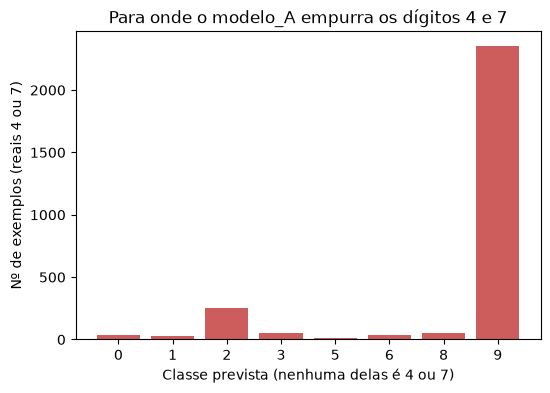

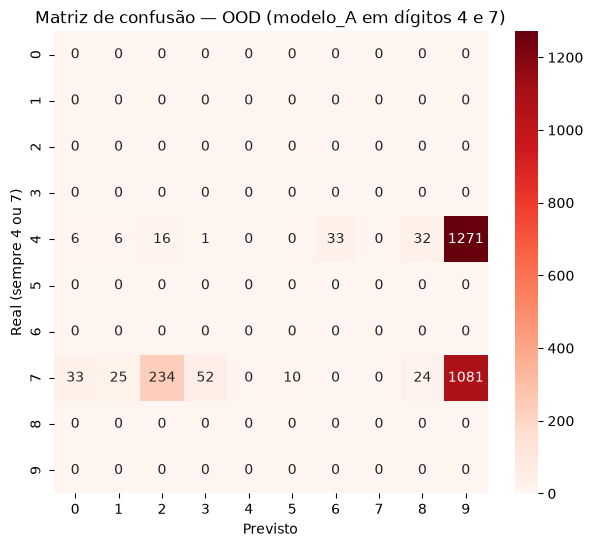

Confiança média nas previsões OOD (todas erradas por definição): 0.5672
Confiança média nas previsões do teste normal (comparação): 0.8158


In [13]:
mask_ood = np.isin(y_test, classes_ocultas)
X_ood = X_test_raw[mask_ood]
y_ood = y_test[mask_ood]           # todos são 4 ou 7

pred_ood = modelo_A.predict(X_ood)
probs_ood = modelo_A.predict_proba(X_ood)
confianca_ood = probs_ood.max(axis=1)   # probabilidade atribuída à classe escolhida

# distribuição das previsões: em que classes conhecidas ele "joga" os 4 e 7?
valores, contagens = np.unique(pred_ood, return_counts=True)
plt.figure(figsize=(6, 4))
plt.bar(valores.astype(str), contagens, color="indianred")
plt.xlabel("Classe prevista (nenhuma delas é 4 ou 7)")
plt.ylabel("Nº de exemplos (reais 4 ou 7)")
plt.title("Para onde o modelo_A empurra os dígitos 4 e 7")
plt.show()

cm_ood = confusion_matrix(y_ood, pred_ood, labels=sorted(set(y_ood) | set(pred_ood)))
plt.figure(figsize=(7, 6))
sns.heatmap(cm_ood, annot=True, fmt='d', cmap='Reds',
            xticklabels=sorted(set(y_ood) | set(pred_ood)),
            yticklabels=sorted(set(y_ood) | set(pred_ood)))
plt.title("Matriz de confusão — OOD (modelo_A em dígitos 4 e 7)")
plt.xlabel("Previsto"); plt.ylabel("Real (sempre 4 ou 7)")
plt.show()

print(f"Confiança média nas previsões OOD (todas erradas por definição): {confianca_ood.mean():.4f}")
print(f"Confiança média nas previsões do teste normal (comparação): "
      f"{rf.predict_proba(X_test_raw).max(axis=1).mean():.4f}")

**TODO (análise — critério nº 8, você escreve):** responda, usando os números e gráficos acima:

- Como o classificador reage a algo que nunca viu? (Ele **não** consegue dizer "não sei" —
  é forçado a escolher entre as 8 classes conhecidas.)
- Para quais classes conhecidas ele empurra os 4 e os 7? Cite os números do gráfico/matriz.
- **"Falsa certeza" (overconfidence):** compare a confiança média nas previsões OOD com a
  confiança média no teste normal. O modelo atribui alta confiança a previsões
  necessariamente erradas? Discuta por que isso é perigoso em um sistema real de IA (ex.: um
  sistema que "tem certeza" de um diagnóstico impossível).

### Desafio C — Dígitos manuscritos próprios

Imagens em `data/meus_digitos/digito_0.png` ... `digito_9.png`, desenhadas com traço branco
sobre fundo preto (já no mesmo padrão de cores do MNIST — sem necessidade de inverter).

In [14]:
from PIL import Image
import cv2
from scipy import ndimage

def preprocessar(caminho, papel_branco=True):
    img = Image.open(caminho).convert('L')          # 1. escala de cinza (L = luminância)
    arr = np.array(img).astype(np.float32)

    # 2. binarização por limiar de Otsu (separa traço do fundo automaticamente)
    _, arr_bin = cv2.threshold(arr.astype(np.uint8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    arr = arr_bin.astype(np.float32)

    if papel_branco:
        arr = 255 - arr                              # 3. inverter: fundo->preto, traço->branco

    # 4. recortar a bounding box do dígito (remover margens vazias)
    coords = np.argwhere(arr > 0)
    y0, x0 = coords.min(axis=0); y1, x1 = coords.max(axis=0)
    recorte = arr[y0:y1+1, x0:x1+1]

    # 5. redimensionar mantendo proporção para caber em ~20x20
    h, w = recorte.shape
    escala = 20.0 / max(h, w)
    novo_h, novo_w = max(1, round(h * escala)), max(1, round(w * escala))
    recorte_r = cv2.resize(recorte, (novo_w, novo_h), interpolation=cv2.INTER_AREA)

    # 6. colar num quadro 28x28 (centralizado geometricamente) e refinar pelo centro de massa
    quadro = np.zeros((28, 28), dtype=np.float32)
    y_off, x_off = (28 - novo_h) // 2, (28 - novo_w) // 2
    quadro[y_off:y_off + novo_h, x_off:x_off + novo_w] = recorte_r

    cy, cx = ndimage.center_of_mass(quadro)
    desloc = (13.5 - cy, 13.5 - cx)
    quadro = ndimage.shift(quadro, desloc)

    quadro = quadro / 255.0                          # 7. normalizar para [0.0, 1.0]
    return quadro.reshape(1, 784)

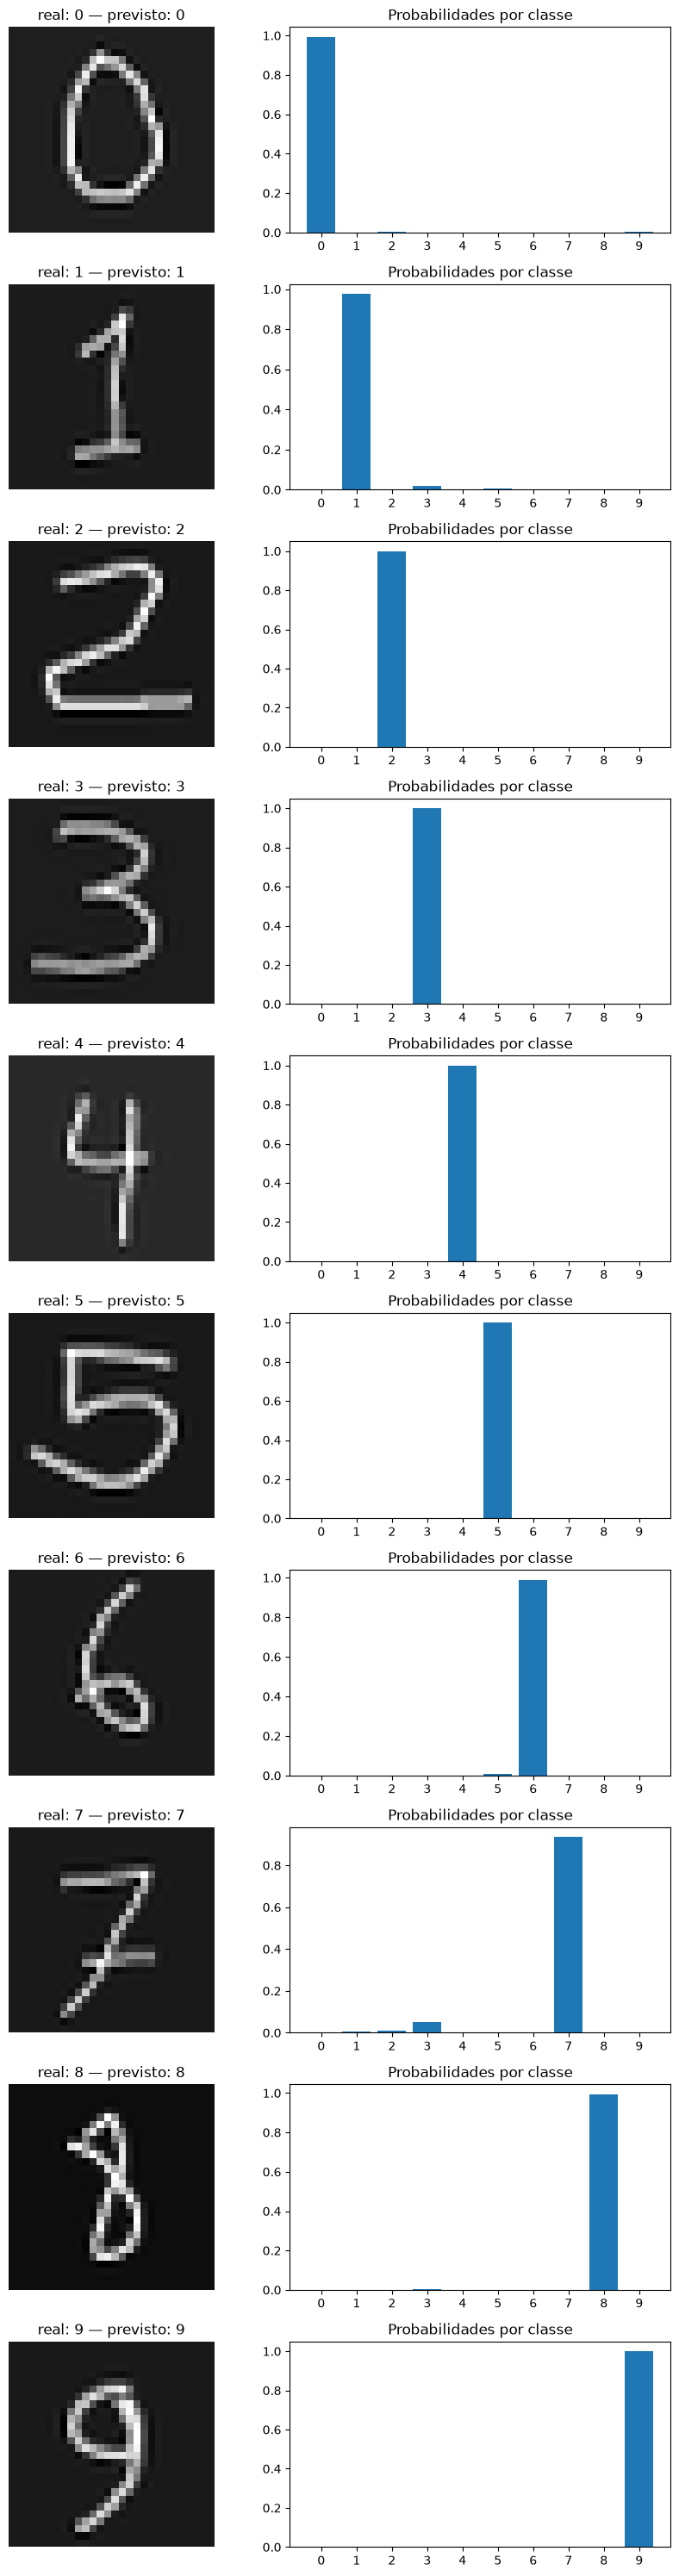

Acurácia nos próprios dígitos manuscritos: 10/10


In [15]:
# Predição com o melhor modelo da Fase 4 (MLP, maior acurácia no teste)
melhor_modelo = mlp
acertos = 0

fig, axes = plt.subplots(10, 2, figsize=(9, 30))
for d in range(10):
    quadro = preprocessar(f"data/meus_digitos/digito_{d}.png", papel_branco=False)
    probs = melhor_modelo.predict(quadro, verbose=0)[0]
    pred = probs.argmax()
    acertos += int(pred == d)

    ax1, ax2 = axes[d]
    ax1.imshow(quadro.reshape(28, 28), cmap='gray')
    ax1.set_title(f"real: {d} — previsto: {pred}")
    ax1.axis('off')
    ax2.bar(range(10), probs)
    ax2.set_title("Probabilidades por classe")
    ax2.set_xticks(range(10))

plt.tight_layout()
plt.show()

print(f"Acurácia nos próprios dígitos manuscritos: {acertos}/10")